In [3]:
'''
colorama==0.4.6
contourpy==1.3.3
cycler==0.12.1
deprecation==2.1.0
fonttools==4.60.1
graphviz==0.21
intervaltree==3.1.0
kiwisolver==1.4.9
lxml==6.0.2
matplotlib==3.10.7
networkx==3.5
numpy==2.3.4
packaging==25.0
pandas==2.3.3
pillow==12.0.0
pydotplus==2.0.2
pyparsing==3.2.5
python-dateutil==2.9.0.post0
pytz==2025.2
scipy==1.16.3
setuptools==80.9.0
six==1.17.0
sortedcontainers==2.4.0
tqdm==4.67.1
tzdata==2025.2
wheel==0.45.1
'''

'\ncolorama==0.4.6\ncontourpy==1.3.3\ncycler==0.12.1\ndeprecation==2.1.0\nfonttools==4.60.1\ngraphviz==0.21\nintervaltree==3.1.0\nkiwisolver==1.4.9\nlxml==6.0.2\nmatplotlib==3.10.7\nnetworkx==3.5\nnumpy==2.3.4\npackaging==25.0\npandas==2.3.3\npillow==12.0.0\npydotplus==2.0.2\npyparsing==3.2.5\npython-dateutil==2.9.0.post0\npytz==2025.2\nscipy==1.16.3\nsetuptools==80.9.0\nsix==1.17.0\nsortedcontainers==2.4.0\ntqdm==4.67.1\ntzdata==2025.2\nwheel==0.45.1\n'

In [4]:
import pandas as pd

df = pd.read_csv('EDHospital.csv')
df

,Case ID,Activity,Complete Timestamp
0,332114754,Reception,4/8/2016 22:38:00
1,332114754,Nurse admission,4/8/2016 22:57:00
2,332114754,Additional vitals,4/8/2016 22:58:00
3,332114754,Last lab tests results,4/8/2016 23:21:00
4,332114754,Doctor admission,4/8/2016 23:33:00
...,...,...,...
461834,332128305,Reception,8/31/2016 19:25:00
461835,332128305,Nurse admission,8/31/2016 20:31:00
461836,332128305,Doctor admission,8/31/2016 20:47:00
461837,332128305,Discharge (Doctor),8/31/2016 20:49:00


In [5]:
import pm4py

log = pm4py.format_dataframe(df,
                             case_id='Case ID',
                             activity_key='Activity',
                             timestamp_key='Complete Timestamp'
                            )
log

,Case ID,Activity,Complete Timestamp,case:concept:name,concept:name,time:timestamp,@@index,@@case_index
0,332040365,Reception,2015-12-31 13:42:00+00:00,332040365,Reception,2015-12-31 13:42:00+00:00,0,0
1,332040365,Nurse admission,2015-12-31 14:17:00+00:00,332040365,Nurse admission,2015-12-31 14:17:00+00:00,1,0
2,332040365,Order blood tests,2015-12-31 14:18:00+00:00,332040365,Order blood tests,2015-12-31 14:18:00+00:00,2,0
3,332040365,Last lab tests results,2015-12-31 14:33:00+00:00,332040365,Last lab tests results,2015-12-31 14:33:00+00:00,3,0
4,332040365,Doctor admission,2015-12-31 15:28:00+00:00,332040365,Doctor admission,2015-12-31 15:28:00+00:00,4,0
...,...,...,...,...,...,...,...,...
461834,332152317,Order Imaging test,2016-08-31 17:25:00+00:00,332152317,Order Imaging test,2016-08-31 17:25:00+00:00,461834,55078
461835,332152317,Imaging,2016-08-31 18:28:00+00:00,332152317,Imaging,2016-08-31 18:28:00+00:00,461835,55078
461836,332152317,Imaging decrypting,2016-08-31 19:27:00+00:00,332152317,Imaging decrypting,2016-08-31 19:27:00+00:00,461836,55078
461837,332152317,Discharge (Doctor),2016-08-31 19:38:00+00:00,332152317,Discharge (Doctor),2016-08-31 19:38:00+00:00,461837,55078


In [6]:
# Most common variants/sequence of activities
variants = pm4py.get_variants(log)

list(variants.keys())[0], variants[list(variants.keys())[0]]

(('Reception',
  'Nurse admission',
  'Order blood tests',
  'Last lab tests results',
  'Doctor admission',
  'Discharge (Doctor)',
  'Discharge'),
 7994)

In [7]:
# most common activities are tied, being Reception and Discharge both at 55079

df['Activity'].value_counts(dropna=False)

Activity
Reception                 55079
Discharge                 55079
Doctor admission          54871
Nurse admission           54300
Discharge (Doctor)        54213
Last lab tests results    41268
Order Imaging test        29730
Order blood tests         28043
Imaging                   27824
Additional vitals         25188
Order Consultant          15192
Consultant                12954
Imaging decrypting         7110
Order external exams        506
External exams              482
Name: count, dtype: int64

In [8]:
variants_paths_duration = pm4py.get_variants_paths_duration(log)

variants_paths_duration

,@@index_in_trace,@@flow_time,@@cumulative_occ_path_column,concept:name,concept:name_2,@@variant_column,@@variant_count
0,0,2002.134101,0,Reception,Nurse admission,"(Reception, Nurse admission, Order blood tests...",7994
1,1,81.128346,0,Nurse admission,Order blood tests,"(Reception, Nurse admission, Order blood tests...",7994
2,2,1586.517388,0,Order blood tests,Last lab tests results,"(Reception, Nurse admission, Order blood tests...",7994
3,3,2210.542907,0,Last lab tests results,Doctor admission,"(Reception, Nurse admission, Order blood tests...",7994
4,4,18348.066050,0,Doctor admission,Discharge (Doctor),"(Reception, Nurse admission, Order blood tests...",7994
...,...,...,...,...,...,...,...
1,1,840.000000,0,Reception,Nurse admission,"(Doctor admission, Reception, Nurse admission,...",1
2,2,60.000000,0,Nurse admission,Order blood tests,"(Doctor admission, Reception, Nurse admission,...",1
3,3,60.000000,0,Order blood tests,Last lab tests results,"(Doctor admission, Reception, Nurse admission,...",1
4,4,20940.000000,0,Last lab tests results,Discharge (Doctor),"(Doctor admission, Reception, Nurse admission,...",1


In [9]:
variants_df = variants_paths_duration[['@@variant_column', '@@variant_count']].drop_duplicates()

In [10]:
# so many variants, how can we just get the single directed ones, is it even possible


variants_df[variants_df['@@variant_count'] == 1], variants_df[variants_df['@@variant_count'] >= 1000]

(                                     @@variant_column  @@variant_count
 0   (Reception, Order blood tests, Order Imaging t...                1
 0   (Reception, Order blood tests, Order Imaging t...                1
 0   (Reception, Order blood tests, Order Imaging t...                1
 0   (Reception, Order blood tests, Order Imaging t...                1
 0   (Reception, Order blood tests, Order Imaging t...                1
 ..                                                ...              ...
 0   (Reception, Additional vitals, Additional vita...                1
 0   (Reception, Additional vitals, Additional vita...                1
 0   (Nurse admission, Order blood tests, Last lab ...                1
 0   (Last lab tests results, Reception, Nurse admi...                1
 0   (Doctor admission, Reception, Nurse admission,...                1
 
 [7703 rows x 2 columns],
                                     @@variant_column  @@variant_count
 0  (Reception, Nurse admission, Orde

In [11]:
import matplotlib.pyplot as plt
import numpy as np

In [12]:
variant_names = variants_df['@@variant_column'].to_numpy()

variant_names.shape

(9537,)

In [13]:
variant_frequencies = variants_df['@@variant_count'].to_numpy()

variant_frequencies.shape

(9537,)

(array([19093.,  3570.,  1921.,  1652.,  1422.,   910.,   495.,   578.,
          715.,     0.,     0.,     0.,   968.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,  2744.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,  3389.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,  4613.,     0.,     0.,     0.,     0.,  5015.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,  7994.]),
 array([1.00000e+00, 8.09300e+01, 1.60860e+02, 2.40790e+02, 3.20720e+02,
        4.00650e+02, 

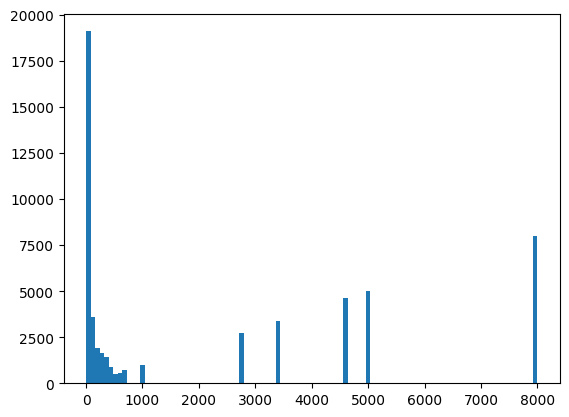

In [14]:
# reverse histogram, we can observe that the most infrequent cases which occur less than 1000 times, also make up a majority of the cases

fig, ax = plt.subplots()
ax.hist(x=variant_frequencies, bins=100, weights=variant_frequencies)

In [15]:
def average_flow_time(activity: str):
    return variants_paths_duration[variants_paths_duration['concept:name'] == activity]['@@flow_time'].mean()

In [ ]:
print(
        'Reception', average_flow_time('Reception'), "\n",
        'Doctor admission', average_flow_time('Doctor admission'), "\n",
        'Nurse admission', average_flow_time('Nurse admission'), "\n",
        'Last lab test results', average_flow_time('Last lab tests results'), "\n",
        'Order imaging test', average_flow_time('Order Imaging test'), "\n",
        'Order blood tests', average_flow_time('Order blood tests'), "\n",
        'Imaging', average_flow_time('Imaging'), 
)

Reception 1965.8355652204884 
 Doctor admission 1047.5144633005245 
 Nurse admission 797.7446639683794 
 Last lab test results 2971.525294618539 
 Order imaging test nan 
 Order blood tests 1456.7610964703638 
 Imaging 4961.356766458055


In [18]:
print('Doctor admission', average_flow_time('Doctor admission'))

Doctor admission 1047.5144633005245
